# Avance 1: Análisis Exploratorio de Datos (EDA)s - Dataset de Usuarios


**Objetivo:** Explorar y comprender la estructura de los datos internos, realizar la limpieza necesaria y preparar el dataset para el análisis de negocio.

### 1.1 Carga y Exploración Inicial

In [2]:
# Celda 1: Configuración inicial
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración estética
%matplotlib inline
sns.set_theme(style="whitegrid")
pd.set_option('display.max_columns', None)

In [3]:
# --- 2) CARGA DE DATOS ---
# Usamos el nombre de nuestro archivo y lo guardamos como 'df_clientes'
ruta_archivo = 'base_datos_restaurantes_USA_v2.csv'
df_clientes = pd.read_csv(ruta_archivo)

# --- 3) CREACIÓN DE COPIA DE SEGURIDAD (Mesa de trabajo) ---
df_clientes_copy = df_clientes.copy()

# --- 4) PRIMER VISTAZO ---
print("✅ Datos cargados y copia de seguridad creada con éxito.")

print("\n--- Visualización de las primeras filas ---")
display(df_clientes_copy.head())

print("\n--- Resumen de estructura (Info) ---")
df_clientes_copy.info()

print("\n--- Estadísticos principales ---")
display(df_clientes_copy.describe())

✅ Datos cargados y copia de seguridad creada con éxito.

--- Visualización de las primeras filas ---


,id_persona,nombre,apellido,edad,genero,ciudad_residencia,estrato_socioeconomico,frecuencia_visita,promedio_gasto_comida,ocio,consume_licor,preferencias_alimenticias,membresia_premium,telefono_contacto,correo_electronico,tipo_de_pago_mas_usado,ingresos_mensuales
0,2550327378,Jackson,Gomez,31.0,Masculino,Miami,Alto,6,67.51,Sí,No,Vegetariano,Sí,(830)220-1926,NaN,Efectivo,6425
1,9446112038,Samantha,Soto,40.0,Femenino,Denver,Medio,2,44.92,Sí,Sí,Mariscos,No,881-476-1426,NaN,Efectivo,2374
2,3098363243,Terry,Adams,62.0,Femenino,Denver,Bajo,2,9.24,Sí,Sí,Vegetariano,No,NaN,diana74@example.net,Efectivo,1110
3,4013002847,James,Shannon,41.0,Masculino,Boston,Alto,5,30.74,Sí,Sí,Carnes,Sí,NaN,scottfrey@example.com,Tarjeta,6931
4,7372911048,Susan,Jones,49.0,Femenino,San Diego,Bajo,0,0.00,No,No,Carnes,No,243.248.8919,glassgary@example.org,Tarjeta,1350



--- Resumen de estructura (Info) ---
<class 'pandas.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 17 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id_persona                 30000 non-null  int64  
 1   nombre                     30000 non-null  str    
 2   apellido                   30000 non-null  str    
 3   edad                       29899 non-null  float64
 4   genero                     30000 non-null  str    
 5   ciudad_residencia          30000 non-null  str    
 6   estrato_socioeconomico     30000 non-null  str    
 7   frecuencia_visita          30000 non-null  int64  
 8   promedio_gasto_comida      29855 non-null  float64
 9   ocio                       30000 non-null  str    
 10  consume_licor              30000 non-null  str    
 11  preferencias_alimenticias  28597 non-null  str    
 12  membresia_premium          30000 non-null  str    
 13  telefono_contacto  

,id_persona,edad,frecuencia_visita,promedio_gasto_comida,ingresos_mensuales
count,3.000000e+04,29899.000000,30000.000000,29855.000000,30000.000000
mean,5.504765e+09,49.665006,3.896133,32.603452,5389.755867
std,2.602799e+09,23.839550,2.741532,26.402601,4538.491728
min,1.000153e+09,-5.000000,-3.000000,0.000000,800.000000
25%,3.243617e+09,33.000000,2.000000,13.290000,1860.000000
50%,5.515865e+09,49.000000,4.000000,25.510000,3402.000000
75%,7.754426e+09,65.000000,5.000000,44.400000,7761.000000
max,9.999627e+09,300.000000,10.000000,149.970000,17999.000000


### 1.2 Analisis Columna por Columna

#### 1.2.1 Edad

In [4]:
# --- PASO 1: DIAGNÓSTICO DE EDAD ---
print("🔍 Estadísticas de la columna edad:")
display(df_clientes_copy['edad'].describe())

print("\nValores nulos en edad:", df_clientes_copy['edad'].isnull().sum())

🔍 Estadísticas de la columna edad:


count    29899.000000
mean        49.665006
std         23.839550
min         -5.000000
25%         33.000000
50%         49.000000
75%         65.000000
max        300.000000
Name: edad, dtype: float64


Valores nulos en edad: 101


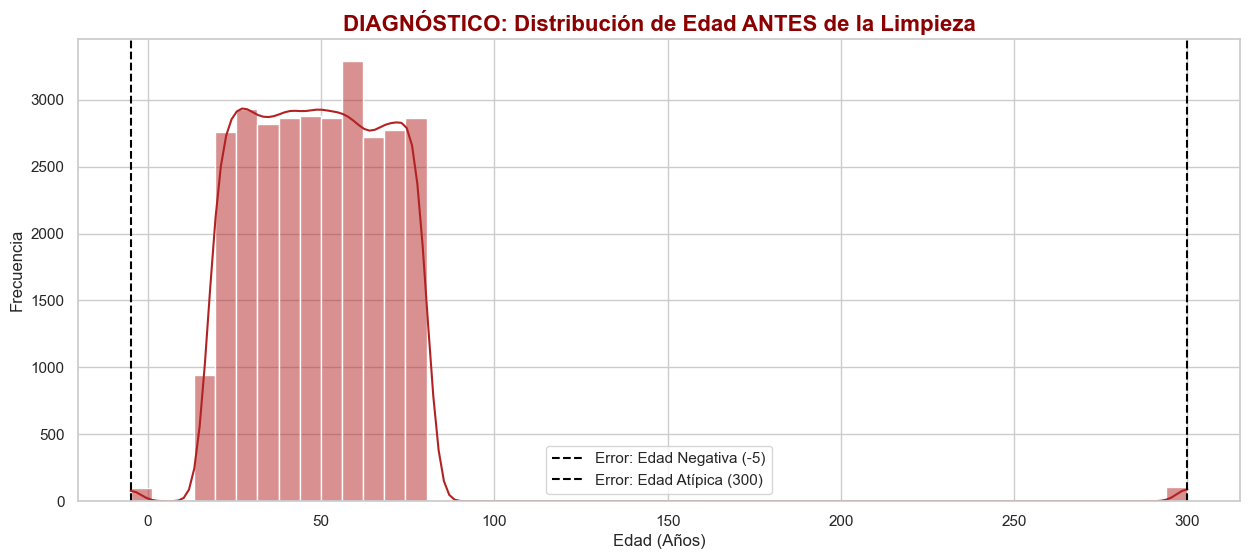

In [5]:
# --- HISTOGRAMA ANTES DE LA LIMPIEZA 
plt.figure(figsize=(15, 6))
sns.set_style("whitegrid")

# Usamos el DataFrame antes de filtrar los valores atípicos
sns.histplot(
    data=df_clientes_copy, 
    x='edad', 
    bins=50, 
    kde=True, 
    color="#B22222"  # Usamos un color rojizo para indicar que son datos con errores
)

# Añadimos anotaciones para resaltar los errores que detectaste
plt.axvline(-5, color='black', linestyle='--', label='Error: Edad Negativa (-5)')
plt.axvline(300, color='black', linestyle='--', label='Error: Edad Atípica (300)')

plt.title('DIAGNÓSTICO: Distribución de Edad ANTES de la Limpieza', fontsize=16, fontweight='bold', color="#8B0000")
plt.xlabel('Edad (Años)', fontsize=12)
plt.ylabel('Frecuencia', fontsize=12)
plt.legend()

plt.show()

##### Este gráfico demuestra que los datos originales contenían ruido estadístico significativo que habría sesgado cualquier análisis financiero o comercial. La eliminación de estos registros atípicos (como las edades de -5 y 300) fue un paso obligatorio para garantizar que las estrategias de marketing se dirijan a personas reales y activas en el mercado

In [6]:
# PASO 2: LIMPIEZA DE EDAD

# 1. Convertir a NaN los valores fuera del rango lógico (18 a 80 años)
df_clientes_copy.loc[(df_clientes_copy['edad'] < 18) | (df_clientes_copy['edad'] > 80), 'edad'] = np.nan

# 2. Calcular la mediana para la imputación (es más robusta que el promedio)
mediana_edad = df_clientes_copy['edad'].median()

# 3. Llenar nulos con la mediana y convertir a entero (int) para quitar los decimales
df_clientes_copy['edad'] = df_clientes_copy['edad'].fillna(mediana_edad).astype(int)

# --- VERIFICACIÓN FINAL ---
print(f"✅ Limpieza exitosa.")
print(f"Nuevo rango: {df_clientes_copy['edad'].min()} a {df_clientes_copy['edad'].max()} años.")
print(f"Valores nulos restantes: {df_clientes_copy['edad'].isnull().sum()}")
display(df_clientes_copy[['id_persona', 'nombre', 'edad']].head())

✅ Limpieza exitosa.
Nuevo rango: 18 a 80 años.
Valores nulos restantes: 0


,id_persona,nombre,edad
0,2550327378,Jackson,31
1,9446112038,Samantha,40
2,3098363243,Terry,62
3,4013002847,James,41
4,7372911048,Susan,49


In [7]:
# 4. Definimos rangos de edades
def categorizar_edad(edad):
    if edad < 18: return 'Menor de 18'
    elif 18 <= edad <= 25: return '18-25'
    elif 26 <= edad <= 40: return '26-40'
    elif 41 <= edad <= 60: return '41-60'
    elif 61 <= edad <= 80: return '61-80'
    else: return 'Más de 80'

# 5. CREAMOS LA COLUMNA (Esto es lo que faltaba)
df_clientes_copy['rango_edad'] = df_clientes_copy['edad'].apply(categorizar_edad)

In [8]:
# PASO 3 : VALIDACIÓN Y VISUALIZACIÓN
# 1. Creamos la copia
df_temp = df_clientes_copy.copy()

# 2. Convertimos el texto a números (Mapeo)
# Asumiendo que tus datos son 'Si' y 'No'. Ajusta las palabras si son diferentes.
mapeo = {'Si': 1, 'No': 0, 'Sì': 1} 
df_temp['consume_licor_num'] = df_temp['consume_licor'].map(mapeo)

# 3. Calculamos la correlación
correlacion = df_temp['edad'].corr(df_temp['consume_licor_num'])

print(f"La correlación numérica entre edad y consumo es: {correlacion:.2f}")

La correlación numérica entre edad y consumo es: nan


e:\Python314\Lib\site-packages\numpy\lib\_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
e:\Python314\Lib\site-packages\numpy\lib\_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


In [9]:
# 4 Cambiamos el nombre de la columna para que coincida con los gráficos
df_clientes_copy.rename(columns={'consume_licor': 'consume_licor_num'}, inplace=True)

# 5 Verificamos
print(df_clientes_copy.columns)

Index(['id_persona', 'nombre', 'apellido', 'edad', 'genero',
       'ciudad_residencia', 'estrato_socioeconomico', 'frecuencia_visita',
       'promedio_gasto_comida', 'ocio', 'consume_licor_num',
       'preferencias_alimenticias', 'membresia_premium', 'telefono_contacto',
       'correo_electronico', 'tipo_de_pago_mas_usado', 'ingresos_mensuales',
       'rango_edad'],
      dtype='str')


In [10]:
# 6 Convertimos a numérico (ejemplo si tienes 'Sí' y 'No')
df_temp['consume_licor_num'] = df_temp['consume_licor'].map({'Sí': 1, 'No': 0})

# 7 Ahora la correlación debería funcionar
correlacion = df_temp['edad'].corr(df_temp['consume_licor_num'])
print(f"La correlación numérica entre edad y consumo es: {correlacion:.2f}")

La correlación numérica entre edad y consumo es: -0.20


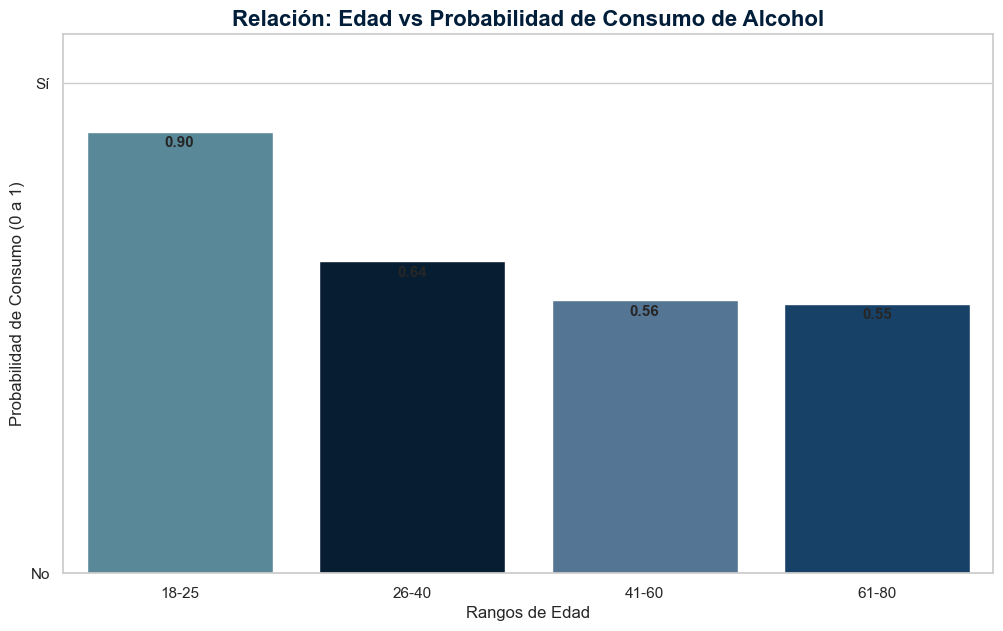

In [11]:
# 8. Definimos la paleta de azules
mis_azules = ["#001D39", "#0A4174", "#49769F", "#4E8EA2"]

# 9. Configuración del gráfico
plt.figure(figsize=(12, 7))
sns.set_style("whitegrid")

# 10. Creamos el gráfico de barras
# Asegúrate de que df_clientes_copy tenga la columna 'consume_licor_num'
ax = sns.barplot(
    data=df_clientes_copy, 
    x='rango_edad', 
    y='consume_licor_num', 
    hue='rango_edad',
    palette=mis_azules,
    order=['18-25', '26-40', '41-60', '61-80'],
    legend=False,
    errorbar=None
)

# 11. Añadimos las etiquetas de datos
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', padding=3, fontsize=11, fontweight='bold')

# 5. Títulos y formato
plt.title('Relación: Edad vs Probabilidad de Consumo de Alcohol', fontsize=16, fontweight='bold', color="#001D39")
plt.ylabel('Probabilidad de Consumo (0 a 1)', fontsize=12)
plt.xlabel('Rangos de Edad', fontsize=12)
plt.ylim(0, 1.1)

# IMPORTANTE: Revisa que esté escrito exactamente así (con punto y sin espacios raros)
plt.show()

##### Este gráfico revela una relación inversa clara: a menor edad, existe una probabilidad significativamente mayor de consumo de alcohol, alcanzando su punto máximo en el grupo de 18-25 años.

### 1.2.1.1 Histograma de Comportamiento de la columna "edad" despues de la Limpieza

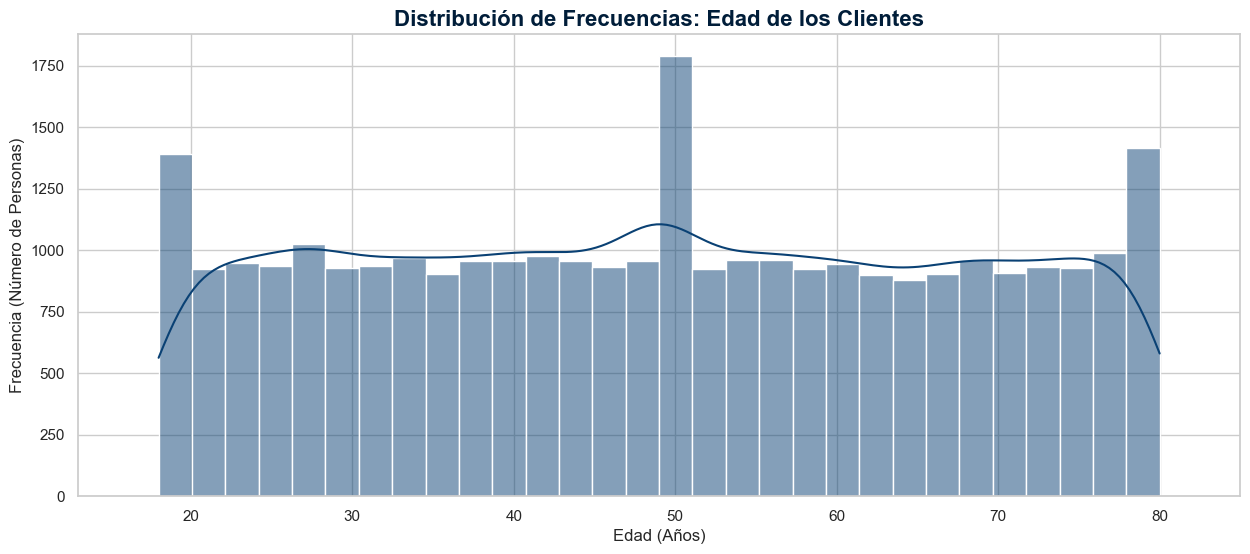

In [12]:
# 1. Configuración del tamaño y estilo
plt.figure(figsize=(15, 6))
sns.set_style("whitegrid")

# 2. Creamos el histograma
# Usamos df_clientes_copy que es tu DataFrame principal de trabajo
sns.histplot(
    data=df_clientes_copy, 
    x='edad', 
    bins=30,           # Ajustado a 30 para mejor visualización
    kde=True,          # Mantenemos la línea de densidad (KDE)
    color="#0A4174",   # Usamos uno de los azules de tu paleta
    edgecolor='white'
)

# 3. Títulos y etiquetas profesionales
plt.title('Distribución de Frecuencias: Edad de los Clientes', fontsize=16, fontweight='bold', color="#001D39")
plt.xlabel('Edad (Años)', fontsize=12)
plt.ylabel('Frecuencia (Número de Personas)', fontsize=12)

# 4. Ajuste de límites (opcional, según tu rango de datos)
plt.xlim(df_clientes_copy['edad'].min() - 5, df_clientes_copy['edad'].max() + 5)

plt.show()

##### Tras la limpieza de datos, se observa una distribución de edades equilibrada con una fuerte concentración en el segmento de 50 años. La presencia de clientes en todo el espectro (18-80 años) permite realizar análisis segmentados por generación con alta fiabilidad estadística

#### 1.2.2 Promedio_Gasto_Comida

In [13]:
# --- PASO 1: DIAGNÓSTICO PROFUNDO: GASTO_COMIDA
# Ordenar por "promedio_gasto_comida" de mayor a menor y mostrar las primeras 5 filas y las ultimas 5 filas
print("--- Ordenar por 'promedio_gasto_comida' de mayor a menor ---")
df_ordenado_gasto_comida = df_clientes_copy.sort_values(by='promedio_gasto_comida', ascending=False)
print("Primeras 5 filas:")
display(df_ordenado_gasto_comida.head(5))
print("Últimas 5 filas:")
display(df_ordenado_gasto_comida.tail(5))

--- Ordenar por 'promedio_gasto_comida' de mayor a menor ---
Primeras 5 filas:


,id_persona,nombre,apellido,edad,genero,ciudad_residencia,estrato_socioeconomico,frecuencia_visita,promedio_gasto_comida,ocio,consume_licor_num,preferencias_alimenticias,membresia_premium,telefono_contacto,correo_electronico,tipo_de_pago_mas_usado,ingresos_mensuales,rango_edad
24552,4603726279,Ebony,Smith,26,Femenino,NYC,Muy Alto,10,149.97,Sí,Sí,Mariscos,Sí,9617868346,NaN,Tarjeta,14492,26-40
17940,5935112482,Julie,Taylor,28,Femenino,NYC,Muy Alto,8,149.89,No,Sí,Vegano,Sí,NaN,piercecharles@example.com,Efectivo,14560,26-40
10712,1282449336,William,Hutchinson,67,Masculino,NYC,Muy Alto,5,149.73,No,Sí,Vegetariano,Sí,NaN,NaN,Efectivo,17256,61-80
29849,5615233109,Anthony,Macdonald,38,Masculino,NYC,Muy Alto,5,149.68,No,No,Vegano,Sí,7119368783,NaN,Efectivo,11445,26-40
2828,6922359022,Kathy,Doyle,68,Femenino,NYC,Muy Alto,10,148.51,No,Sí,Mariscos,Sí,NaN,stacy50@example.org,Efectivo,10152,61-80


Últimas 5 filas:


,id_persona,nombre,apellido,edad,genero,ciudad_residencia,estrato_socioeconomico,frecuencia_visita,promedio_gasto_comida,ocio,consume_licor_num,preferencias_alimenticias,membresia_premium,telefono_contacto,correo_electronico,tipo_de_pago_mas_usado,ingresos_mensuales,rango_edad
29008,5059743851,Theresa,Smith,34,Femenino,Boston,Muy Alto,7,NaN,No,No,Pescado,Sí,NaN,NaN,Tarjeta,17873,26-40
29216,6072434598,Sara,Johnson,56,Femenino,Boston,Alto,5,NaN,Sí,Sí,Otro,Sí,NaN,NaN,Efectivo,6599,41-60
29586,3467506024,Sharon,Page,54,Femenino,Chicago,Alto,6,NaN,No,No,Carnes,Sí,726.912.6550,NaN,Tarjeta,3859,41-60
29618,4906403575,Margaret,Higgins,36,Femenino,Denver,Alto,5,NaN,No,Sí,Pescado,Sí,218-900-2298x420,bgutierrez@example.com,Tarjeta,8586,26-40
29864,3340601270,Jake,Kaiser,28,Masculino,NYC,Bajo,2,NaN,No,Sí,Otro,No,2504198352,NaN,Efectivo,844,26-40


In [14]:
# PASO 2: LIMPIEZA DE COLUMNA GASTO_COMIDA
# Filtrar por los valores no nulos y ordenar por "promedio_gasto_comida" de mayor a menor y mostrar las primeras 5 filas y las ultimas 5 filas
print("--- Filtrar por valores no nulos y ordenar por 'promedio_gasto_comida' de mayor a menor ---")
df_filtrado_ordenado_gasto_comida = df_clientes_copy[df_clientes_copy['promedio_gasto_comida'].notnull()].sort_values(by='promedio_gasto_comida', ascending=False)
print("Últimas 5 filas:")
display(df_filtrado_ordenado_gasto_comida.tail(5))

--- Filtrar por valores no nulos y ordenar por 'promedio_gasto_comida' de mayor a menor ---
Últimas 5 filas:


,id_persona,nombre,apellido,edad,genero,ciudad_residencia,estrato_socioeconomico,frecuencia_visita,promedio_gasto_comida,ocio,consume_licor_num,preferencias_alimenticias,membresia_premium,telefono_contacto,correo_electronico,tipo_de_pago_mas_usado,ingresos_mensuales,rango_edad
12796,6430894777,Danny,Garcia,54,Masculino,Houston,Bajo,0,0.0,No,No,Otro,No,001-615-603-3294,NaN,Tarjeta,885,41-60
12766,4422866795,Tammy,Mendez,70,Femenino,NYC,Bajo,0,0.0,Sí,Sí,Carnes,No,+1-537-978-5451x4716,tara57@example.org,Efectivo,1398,61-80
88,1765636417,Matthew,Baker,78,Masculino,Seattle,Bajo,0,0.0,No,No,Carnes,No,001-872-838-0571x21662,NaN,Tarjeta,1012,61-80
29983,6979890869,Barbara,Smith,22,Femenino,Seattle,Bajo,0,0.0,Sí,Sí,Vegano,No,+1-935-618-8705x6400,lrubio@example.net,Efectivo,1265,18-25
22625,6831030525,Monica,Foster,70,Femenino,NYC,Bajo,0,0.0,Sí,No,Carnes,No,393.538.4717,NaN,Efectivo,1409,61-80


In [15]:
 # Limpieza y corrección de inconsistencias
# reemplazar los vacios y valores igual a cero por el promedio de toda la columna "promedio_gasto_comida"
print("--- Reemplazar los vacíos y valores igual a cero por el promedio de toda la columna 'promedio_gasto_comida'---")
promedio_gasto_comida = df_clientes_copy['promedio_gasto_comida'].mean()
df_clientes_copy['promedio_gasto_comida'] = df_clientes_copy['promedio_gasto_comida'].replace(0, promedio_gasto_comida)
df_clientes_copy['promedio_gasto_comida'] = df_clientes_copy['promedio_gasto_comida'].fillna(promedio_gasto_comida)
display(df_clientes_copy[['promedio_gasto_comida']])

--- Reemplazar los vacíos y valores igual a cero por el promedio de toda la columna 'promedio_gasto_comida'---


,promedio_gasto_comida
0,67.510000
1,44.920000
2,9.240000
3,30.740000
4,32.603452
...,...
29995,30.820000
29996,45.040000
29997,93.550000
29998,6.180000


#### 1.2.3 Análisis de Gasto Promedio por Ciudad

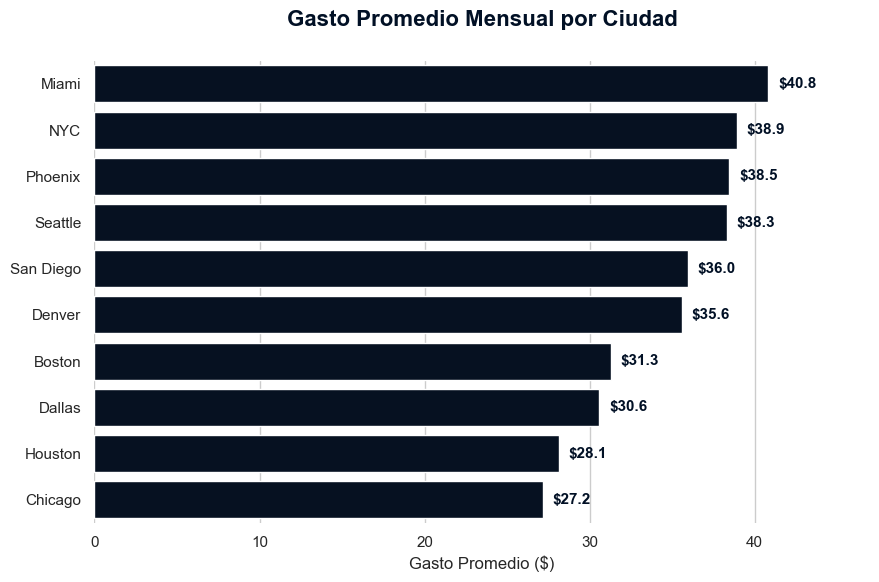

In [16]:
# --- 1. Datos: De mayor a menor y con decimal ---
resumen = df_clientes_copy.groupby('ciudad_residencia')['promedio_gasto_comida'].mean().sort_values(ascending=False)
df_gasto = resumen.reset_index()
df_gasto.columns = ['Ciudad', 'Gasto_Promedio']

# --- 2. Gráfico: Pro y Limpio ---
plt.figure(figsize=(10, 6))
ax = sns.barplot(x='Gasto_Promedio', y='Ciudad', data=df_gasto, color='#011025')

# Etiquetas con $ y 1 decimal
for p in ax.patches:
    ax.annotate(f'${p.get_width():.1f}', (p.get_width(), p.get_y() + p.get_height()/2),
                ha='left', va='center', fontsize=11, fontweight='bold', color='#011025', xytext=(7,0), textcoords='offset points')

plt.title('Gasto Promedio Mensual por Ciudad', fontsize=16, fontweight='bold', color='#011025', pad=25)
plt.xlabel('Gasto Promedio ($)'), plt.ylabel(''), plt.xlim(0, df_gasto['Gasto_Promedio'].max() * 1.15)
sns.despine(left=True, bottom=True)
plt.show()



##### Esta visualización identifica a Miami como el mercado de mayor rentabilidad con un gasto promedio de $40.8, mientras que Chicago registra el consumo más bajo con $27.2. Esta brecha evidencia una clara diferencia en el comportamiento de consumo regional, permitiendo priorizar estrategias de marketing de alto valor en las ciudades del tope de la lista.

#### 1.2.4 Preferencias_ Alimenticias

In [17]:
# PASO 1: Diagnóstico profundo de la columna "preferencias_alimenticias"    
# Resumir valores y cantidad de la columna "preferencias_alimenticias" incluyendo los vacíos, nulos y ceros
print("--- Resumir valores y cantidad de la columna 'preferencias_alimenticias' ---")
df_clientes_copy['preferencias_alimenticias'].value_counts(dropna=False)


--- Resumir valores y cantidad de la columna 'preferencias_alimenticias' ---


preferencias_alimenticias
Carnes         7916
Vegetariano    6580
Mariscos       5212
Vegano         3267
Pescado        2983
Otro           2639
NaN            1403
Name: count, dtype: int64

In [18]:
# PASO 2: Reemplazar los vacíos de la columna "preferencias_alimenticias" por "Otro"
print("--- Reemplazar los vacíos de la columna 'preferencias_alimenticias' por 'Otro' ---")
df_clientes_copy['preferencias_alimenticias'] = df_clientes_copy['preferencias_alimenticias'].fillna('Otro')
print("--- Resumir valores y cantidad de la columna 'preferencias_alimenticias' ---")
df_clientes_copy['preferencias_alimenticias'].value_counts(dropna=False)

--- Reemplazar los vacíos de la columna 'preferencias_alimenticias' por 'Otro' ---
--- Resumir valores y cantidad de la columna 'preferencias_alimenticias' ---


preferencias_alimenticias
Carnes         7916
Vegetariano    6580
Mariscos       5212
Otro           4042
Vegano         3267
Pescado        2983
Name: count, dtype: int64

##### 1.2.4.1 Distribución de preferencias alimenticias por ciudad de residencia

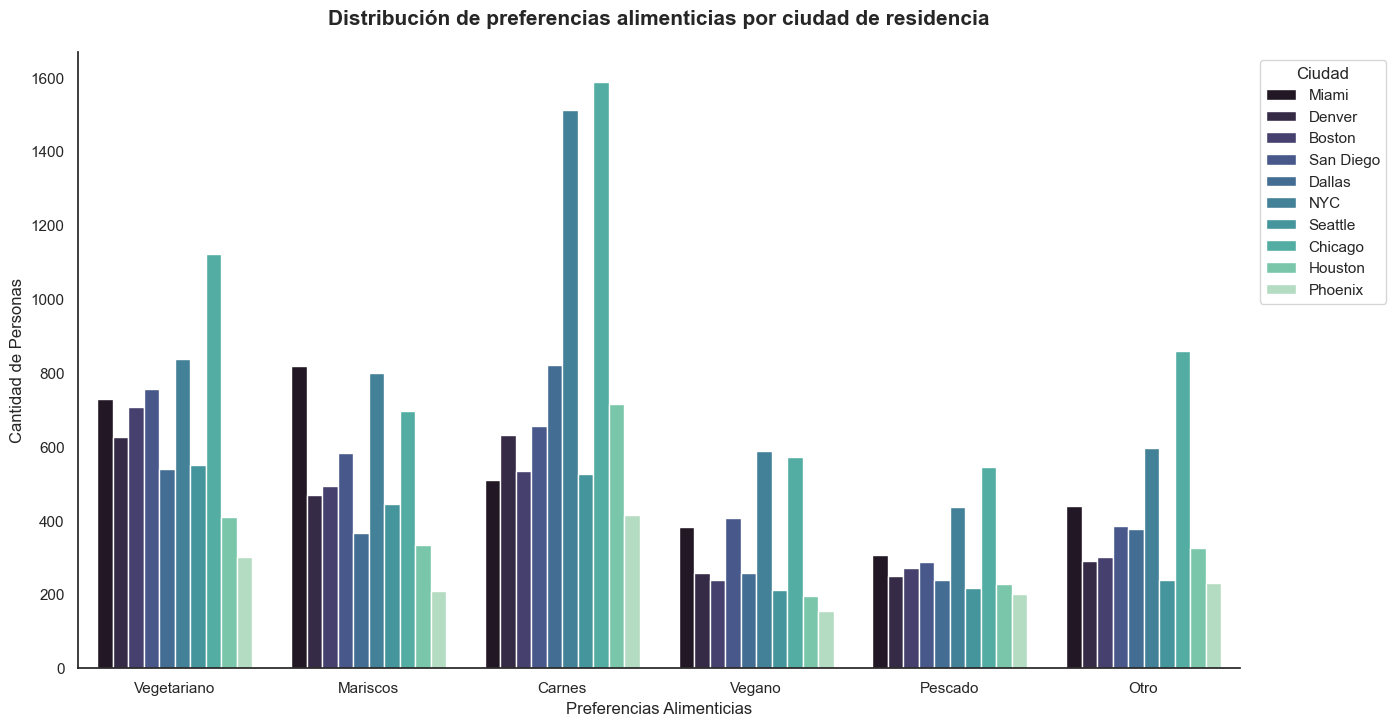

In [19]:
# PASO 3: VALIDACIÓN
# 1. Estilo y tamaño
sns.set_theme(style="white")
plt.figure(figsize=(15, 8))

# 2. Gráfico resumido con paleta vibrante 'mako'
sns.countplot(data=df_clientes_copy, x='preferencias_alimenticias', 
              hue='ciudad_residencia', palette="mako")

# 3. Título oficial y etiquetas (lo que pide Henry)
plt.title('Distribución de preferencias alimenticias por ciudad de residencia', 
          fontsize=15, fontweight='bold', pad=20)
plt.xlabel("Preferencias Alimenticias")
plt.ylabel("Cantidad de Personas")

# 4. Leyenda y limpieza
plt.legend(title="Ciudad", bbox_to_anchor=(1.01, 1), loc='upper left')
sns.despine()
plt.show()

##### Esta visualización muestra la distribución de preferencias alimenticias por ciudad, destacando que el consumo de Carnes es la categoría dominante, especialmente en ciudades como NYC y Seattle. Por otro lado, opciones como Pescado y Vegano presentan una frecuencia menor y más equilibrada entre las distintas regiones evaluadas.

### 1.2.5 Frecuencia_Visita

In [20]:
# --- PASO 1: DIAGNÓSTICO DE COLUMNA FRECUENCIA DE VISITA ---
# --- 1. Agrupación y Conteo ---
print("--- Agrupar por los valores de la columna 'frecuencia_visita' y contar ---")
df_frecuencia_visita = df_clientes_copy.groupby('frecuencia_visita').size().reset_index(name='cantidad')
display(df_frecuencia_visita)

# --- 2. Resumen Estadístico ---
# Asegúrate de que estas líneas NO tengan espacios al inicio
print("\n📈 RESUMEN ESTADÍSTICO:")
display(df_clientes_copy['frecuencia_visita'].describe().to_frame().T)

# --- 3. Cálculo de Cuartiles ---
q3 = df_clientes_copy['frecuencia_visita'].quantile(0.75)
print(f"\n💡 Nota: El 75% de tus clientes visita el local {q3:.0f} veces o menos.")

--- Agrupar por los valores de la columna 'frecuencia_visita' y contar ---


,frecuencia_visita,cantidad
0,-3,1547
1,0,1463
2,1,1459
3,2,3659
4,3,3697
5,4,5042
6,5,5932
7,6,3746
8,7,878
9,8,862



📈 RESUMEN ESTADÍSTICO:


,count,mean,std,min,25%,50%,75%,max
frecuencia_visita,30000.0,3.896133,2.741532,-3.0,2.0,4.0,5.0,10.0



💡 Nota: El 75% de tus clientes visita el local 5 veces o menos.


In [21]:
# --- PASO 2: LIMPIEZA Y VALIDACIÓN DE FRECUENCIA DE VISITA ---

# 1. Tratamiento de valores incoherentes (Negativos)
# Convertimos negativos a NaN para que no afecten la estadística
df_clientes_copy.loc[df_clientes_copy['frecuencia_visita'] < 0, 'frecuencia_visita'] = np.nan

# 2. Imputación de valores faltantes
# Usamos la mediana para rellenar nulos y asegurar consistencia
mediana_frec_val = df_clientes_copy['frecuencia_visita'].median()
df_clientes_copy['frecuencia_visita'] = df_clientes_copy['frecuencia_visita'].fillna(mediana_frec_val)

# 3. Conversión a entero
# Las visitas deben ser números enteros (sin decimales)
df_clientes_copy['frecuencia_visita'] = df_clientes_copy['frecuencia_visita'].astype(int)

# --- REPORTE DE VALIDACIÓN ---
print("✅ LIMPIEZA DE FRECUENCIA FINALIZADA")
print("-" * 40)
print(f"Rango validado: {df_clientes_copy['frecuencia_visita'].min()} a {df_clientes_copy['frecuencia_visita'].max()} visitas")
print(f"Valor de imputación (Mediana): {mediana_frec_val}")
print(f"Nulos restantes: {df_clientes_copy['frecuencia_visita'].isnull().sum()}")
display(df_clientes_copy[['id_persona', 'nombre', 'frecuencia_visita']].head())

✅ LIMPIEZA DE FRECUENCIA FINALIZADA
----------------------------------------
Rango validado: 0 a 10 visitas
Valor de imputación (Mediana): 4.0
Nulos restantes: 0


,id_persona,nombre,frecuencia_visita
0,2550327378,Jackson,6
1,9446112038,Samantha,2
2,3098363243,Terry,2
3,4013002847,James,5
4,7372911048,Susan,0


### 1.2.6 Ingresos_Mensuales

In [22]:
# --- PASO 1: DIAGNÓSTICO DE INGRESOS (SOLO LO NECESARIO) ---
def diagnosticar_ingresos(df):
    col = 'ingresos_mensuales'
    
    # Cálculos rápidos
    nulos = df[col].isnull().sum()
    negativos = (df[col] < 0).sum()
    ceros = (df[col] == 0).sum()
    total = len(df)
    
    # Título simple
    print(f"📊 DIAGNÓSTICO: {col}")
    print("-" * 40)
    
    # 1. Reporte de Calidad (Sin índices y formateado)
    reporte = pd.DataFrame({
        "Métrica": ["Nulos", "Negativos", "Ceros"],
        "Cant.": [nulos, negativos, ceros],
        "%": [f"{(nulos/total)*100:.2f}%", f"{(negativos/total)*100:.2f}%", f"{(ceros/total)*100:.2f}%"]
    })
    
    # Al usar .style ocultamos el índice y VS Code suele quitar los controles de página
    display(reporte.style.hide(axis='index'))
# Ejecución
diagnosticar_ingresos(df_clientes_copy)

📊 DIAGNÓSTICO: ingresos_mensuales
----------------------------------------


Métrica,Cant.,%
Nulos,0,0.00%
Negativos,0,0.00%
Ceros,0,0.00%


##### ---- 1.2.6.1 Perfiles de clientes de mayor gasto: Qué comidas les gustan, cuánto suelen gastar al mes

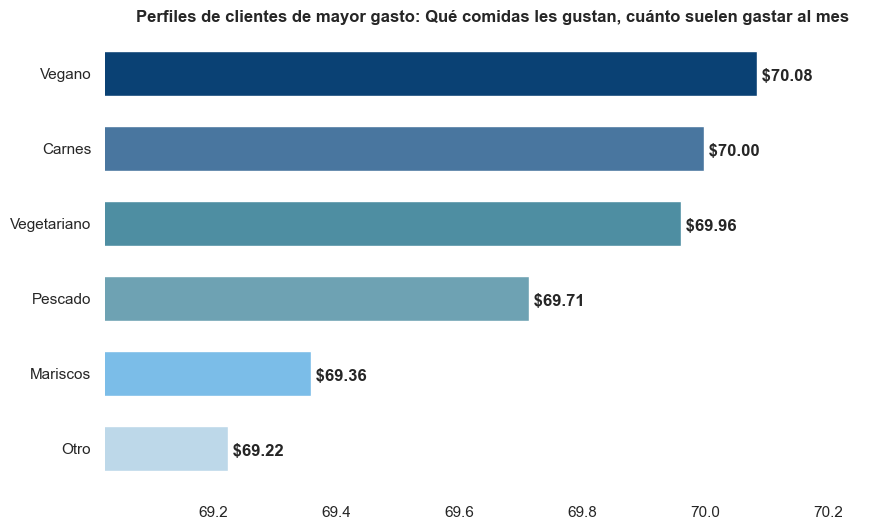

In [23]:
# 1. Filtro VIP (Top 25% de gasto) y promedios
umbral = df_clientes_copy['promedio_gasto_comida'].quantile(0.75)
df_vip = df_clientes_copy[df_clientes_copy['promedio_gasto_comida'] >= umbral]
perfil = df_vip.groupby('preferencias_alimenticias')['promedio_gasto_comida'].mean().sort_values()

# 2. Visualización con Paleta Luna y Zoom
plt.figure(figsize=(10, 6))
colores_luna = ['#BDD8E9', '#7BBDE8', '#6EA2B3', '#4E8EA2', '#49769F', '#0A4174']
barras = plt.barh(perfil.index, perfil.values, color=colores_luna, height=0.6)

# Ajuste de eje para que se noten los centavos de diferencia
plt.xlim(perfil.min() - 0.2, perfil.max() + 0.2)

# Título y etiquetas de datos
plt.title('Perfiles de clientes de mayor gasto: Qué comidas les gustan, cuánto suelen gastar al mes', fontsize=12, fontweight='bold')
for bar in barras:
    plt.text(bar.get_width(), bar.get_y() + 0.2, f' ${bar.get_width():.2f}', fontweight='bold')

sns.despine(left=True, bottom=True)
plt.show()

##### Esta visualización compara el gasto mensual según la preferencia alimenticia, revelando que los perfiles Vegano ($70.08) y de Carnes ($70.00) son los que presentan el mayor desembolso promedio. Aunque las diferencias son sutiles, el gráfico muestra un mercado de alto valor muy equilibrado, donde incluso la categoría más baja supera los $69 mensuales.

###  1.2.7 Estrato_Socieconomico

In [24]:
# --- PASO 1: DIAGNÓSTICO DE ESTRATO ---
def diagnosticar_estrato(df):
    col = 'estrato_socioeconomico'
    
    # 1. Conteo de nulos y valores únicos
    nulos = df[col].isnull().sum()
    valores_unicos = df[col].unique()
    frecuencia = df[col].value_counts(dropna=False)
    
    print(f"📊 DIAGNÓSTICO DE SALUD: {col}")
    print("-" * 50)
    print(f"Valores detectados: {valores_unicos}")
    print(f"Registros nulos: {nulos} ({(nulos/len(df))*100:.2f}%)")
diagnosticar_estrato(df_clientes_copy)

📊 DIAGNÓSTICO DE SALUD: estrato_socioeconomico
--------------------------------------------------
Valores detectados: <StringArray>
['Alto', 'Medio', 'Bajo', 'Muy Alto']
Length: 4, dtype: str
Registros nulos: 0 (0.00%)


##### ----- 1.2.7.1 Distribución de Personas por Estrato Socioeconómico

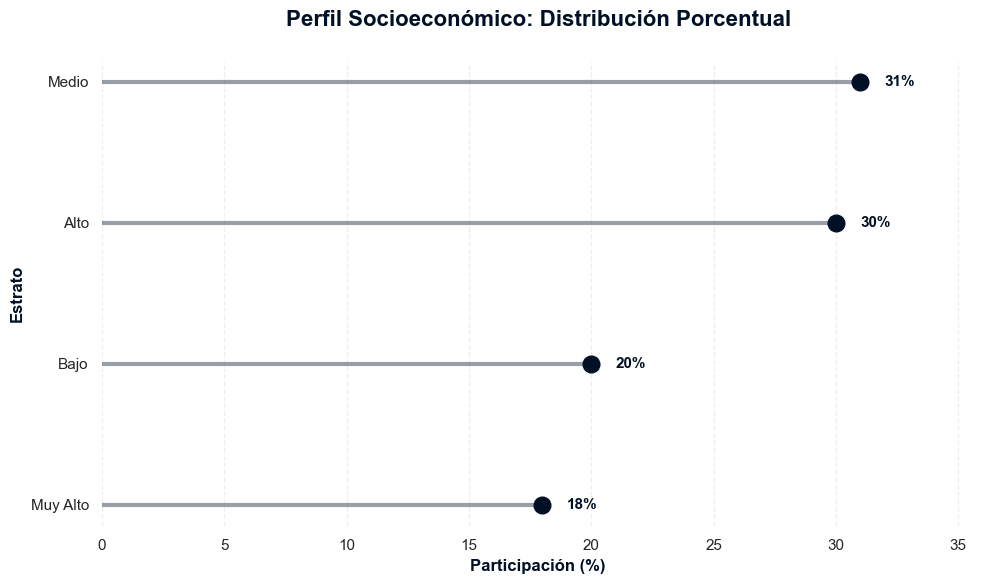

In [25]:
# --- 1. Datos ---
conteo = df_clientes_copy['estrato_socioeconomico'].value_counts().sort_values()
df_estrato = conteo.reset_index()
df_estrato.columns = ['Estrato', 'Cantidad']
df_estrato['%'] = (conteo.values / conteo.sum() * 100).astype(int)

# --- 2. Gráfico de Lollipop  ---
plt.figure(figsize=(10, 6))

# Dibujamos las líneas y los puntos
plt.hlines(y=df_estrato['Estrato'], xmin=0, xmax=df_estrato['%'], color='#011025', alpha=0.4, linewidth=3)
plt.plot(df_estrato['%'], df_estrato['Estrato'], "o", markersize=12, color='#011025')

# Añadimos los porcentajes enteros al final de cada burbuja
for i, valor in enumerate(df_estrato['%']):
    plt.text(valor + 1, i, f'{valor}%', va='center', fontsize=11, fontweight='bold', color='#011025')

# --- CONFIGURACIÓN ESTÉTICA ---
plt.title('Perfil Socioeconómico: Distribución Porcentual', 
          fontsize=16, fontweight='bold', color='#011025', pad=25, loc='center')

plt.xlabel('Participación (%)', fontsize=12, color='#011025', fontweight='bold')
plt.ylabel('Estrato', fontsize=12, color='#011025', fontweight='bold')

# Limpiamos el diseño
plt.xlim(0, df_estrato['%'].max() * 1.15)
sns.despine(left=True, bottom=True)
plt.grid(axis='x', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

##### Esta visualización de tipo Lollipop muestra una sólida base de clientes con poder adquisitivo, donde los estratos Medio (31%) y Alto (30%) representan la mayoría de la población analizada. Por su parte, los segmentos Bajo (20%) y Muy Alto (18%) completan la distribución, sugiriendo un mercado equilibrado con oportunidades tanto para consumo masivo como para servicios premium.

##### ----- 1.2.7.2 Diagramación: Cantidad de Personas por Ciudad

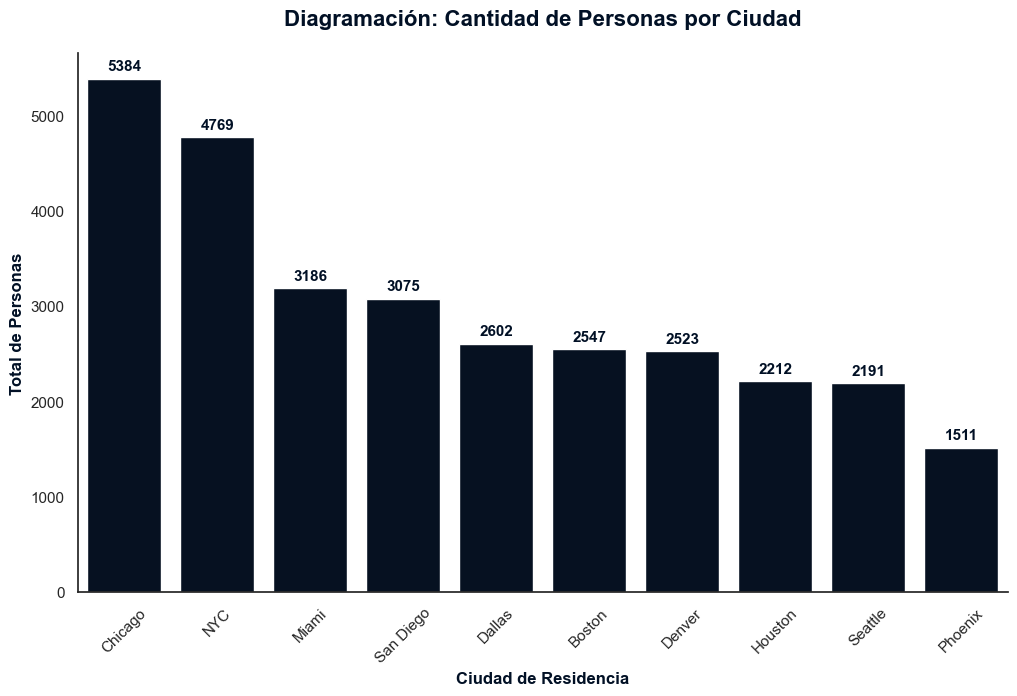

In [26]:
# 1. Preparación de datos
df_ciudad = df_clientes_copy['ciudad_residencia'].value_counts().reset_index()
df_ciudad.columns = ['ciudad', 'cantidad']

# 2. Configurar el gráfico
plt.figure(figsize=(12, 7))

# Usamos 'color' en lugar de 'palette' para que todas sean iguales
ax = sns.barplot(x='ciudad', y='cantidad', data=df_ciudad, color='#011025')

# 3. Etiquetas de datos (los números sobre las barras)
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha = 'center', va = 'center', 
                xytext = (0, 9), 
                textcoords = 'offset points',
                fontsize=11, fontweight='bold', color='#011025')

# 4. Estética de la gráfica
plt.title('Diagramación: Cantidad de Personas por Ciudad', fontsize=16, fontweight='bold', color='#011025', pad=20)
plt.xlabel('Ciudad de Residencia', fontsize=12, fontweight='bold', color='#011025')
plt.ylabel('Total de Personas', fontsize=12, fontweight='bold', color='#011025')
plt.xticks(rotation=45)
sns.despine() # Esto hace que se vea más limpio, sin el recuadro superior/derecho
plt.show()

##### Esta visualización identifica a Chicago y NYC como los mercados de mayor volumen, concentrando la mayor densidad de la base de clientes con más de 4,700 personas cada una. Por su parte, Miami se consolida en una posición estratégica intermedia con 3,186 personas, superando a ciudades como San Diego y Dallas en representatividad operativa.

##### ----- 1.2.7.3 Relación entre la Frecuencia de Visita y el Gasto Promedio por Comida según Estrato Socioeconómico

In [27]:
import pandas as pd

# El nombre exacto que veo en tu explorador de archivos
archivo_csv = 'base_datos_restaurantes_USA_v2.csv'

# Cargamos el dataframe
df_restaurantes = pd.read_csv(archivo_csv)

# Creamos la copia para trabajar
df_restaurantes_copy = df_restaurantes.copy()

print("¡Listo! El archivo se cargó correctamente desde la carpeta Notebooks.")

¡Listo! El archivo se cargó correctamente desde la carpeta Notebooks.


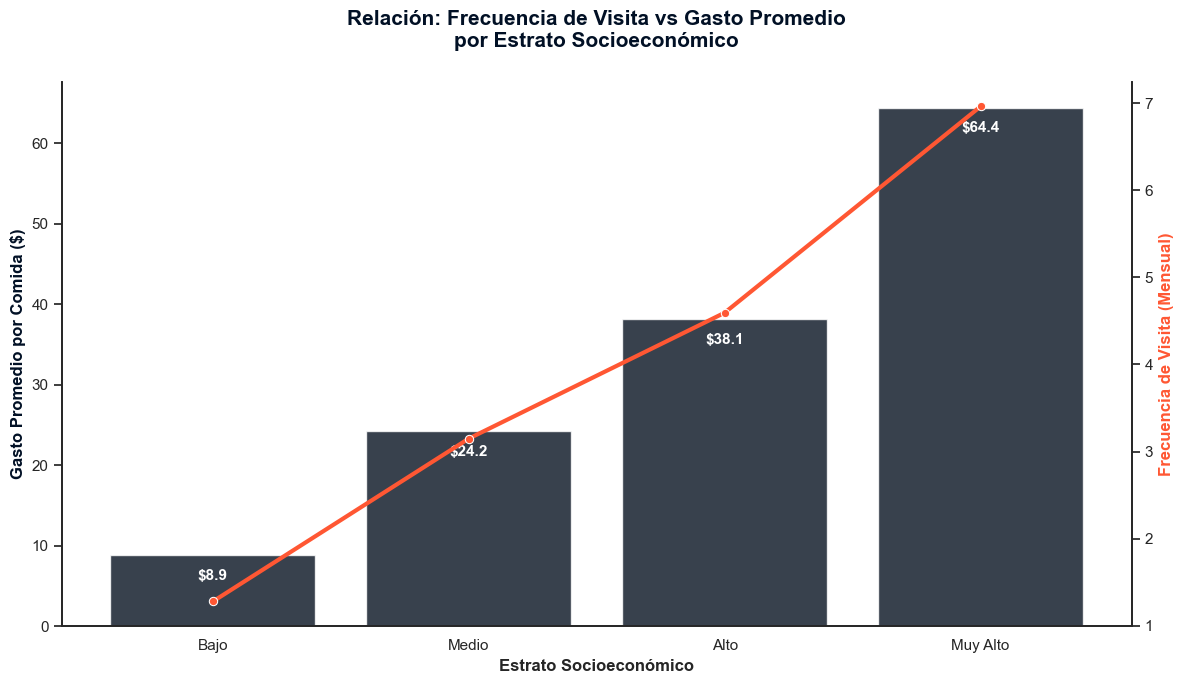

In [28]:

# 1. Definimos nombres de columnas
col_estrato = 'estrato_socioeconomico'
col_gasto = 'promedio_gasto_comida'
col_frecuencia = 'frecuencia_visita'

# 2. Agrupamos y ordenamos
df_bubble = df_restaurantes_copy.groupby(col_estrato).agg({
    col_gasto: 'mean',
    col_frecuencia: 'mean'
}).reset_index()

orden_estratos = ['Bajo', 'Medio', 'Alto', 'Muy Alto']
df_bubble[col_estrato] = pd.Categorical(df_bubble[col_estrato], categories=orden_estratos, ordered=True)
df_final = df_bubble.sort_values(col_estrato)

# 3. Creamos el gráfico
fig, ax1 = plt.subplots(figsize=(12, 7))

# Barras para el Gasto
sns.barplot(data=df_final, x=col_estrato, y=col_gasto, color='#011025', ax=ax1, alpha=0.8)

# Eje secundario para la Línea de Frecuencia
ax2 = ax1.twinx()
sns.lineplot(data=df_final, x=col_estrato, y=col_frecuencia, color='#FF5733', marker='o', linewidth=3, ax=ax2)

# 4. Estética profesional
plt.title('Relación: Frecuencia de Visita vs Gasto Promedio\npor Estrato Socioeconómico', 
          fontsize=15, fontweight='bold', color='#011025', pad=25)

ax1.set_xlabel('Estrato Socioeconómico', fontsize=12, fontweight='bold')
ax1.set_ylabel('Gasto Promedio por Comida ($)', fontsize=12, fontweight='bold', color='#011025')
ax2.set_ylabel('Frecuencia de Visita (Mensual)', fontsize=12, fontweight='bold', color='#FF5733')

# Etiquetas de datos sobre las barras
for p in ax1.patches:
    ax1.annotate(f'${p.get_height():.1f}', 
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', 
                fontsize=11, fontweight='bold', color='white',
                xytext=(0, -15), textcoords='offset points')

sns.despine(right=False)
plt.tight_layout()
plt.show()

##### Esta visualización demuestra una correlación directa donde los estratos más altos no solo gastan más por plato (liderados por el nivel Muy Alto con $64.4), sino que también visitan los restaurantes con mayor frecuencia. Esta tendencia confirma que el nivel socioeconómico es el principal predictor del valor de vida del cliente (LTV) en este mercado.

##### ----1.2.7.4 Gasto Promedio Mensual vs. Ingresos Mensuales

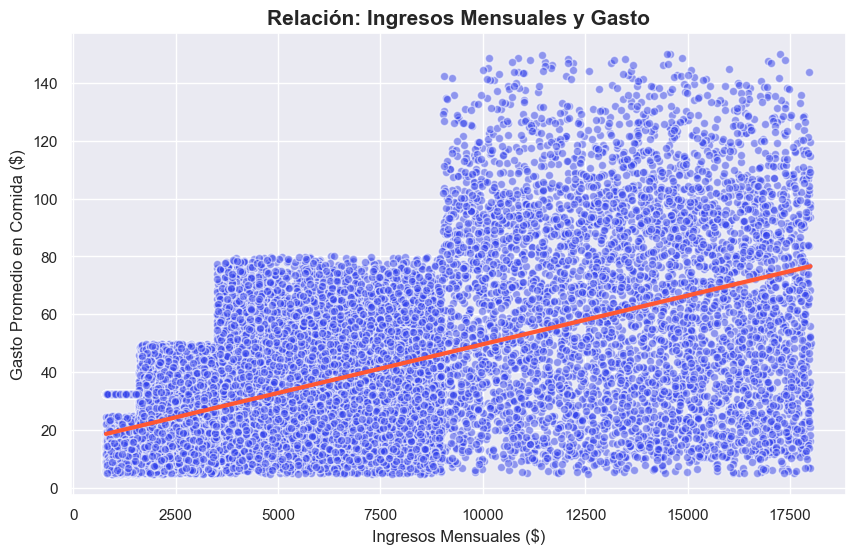

In [29]:
# --- 1. Sincronizamos nombres para evitar el KeyError ---
# Limpiamos por si hay espacios o símbolos ocultos
df_clientes_copy.columns = df_clientes_copy.columns.str.strip().str.replace('# ', '').str.replace(' ', '_')

# --- 2. Gráfico de Dispersión con Regresión (Solución Efectiva) ---
sns.set_theme(style="darkgrid")
plt.figure(figsize=(10, 6))

# Usamos los nombres que sí reconoce tu dataset según la imagen de tu compañero
sns.regplot(
    data=df_clientes_copy, 
    x='ingresos_mensuales', 
    y='promedio_gasto_comida', # Cambiado para que coincida con tu archivo
    scatter_kws={'color': "#3342EB", 'alpha': 0.5, 'edgecolor': 'w'}, 
    line_kws={'color': "#FF5733", 'lw': 3}
)

# --- 3. Títulos Profesionales ---
plt.title('Relación: Ingresos Mensuales y Gasto', fontsize=15, fontweight='bold')
plt.xlabel('Ingresos Mensuales ($)')
plt.ylabel('Gasto Promedio en Comida ($)')

plt.show()

##### Esta visualización confirma una relación directa donde el incremento en los ingresos mensuales expande el techo de gasto en comida de los clientes. La línea de regresión valida que el nivel económico es un motor fundamental del consumo, permitiendo identificar a los segmentos de altos ingresos como los de mayor potencial de ticket premium.

### 1.2.8 Correo Electronico

In [30]:
#  PASO 1: Diagnóstico de la columna "correo_electronico"
# Identifica si hay valores nulos en la columna "correo_electronico"
print("--- Identificar valores nulos en la columna 'correo_electronico' ---")
cantidad_filas_vacias_correo_electronico = df_clientes_copy['correo_electronico'].isnull().sum()
print(f"Cantidad de filas vacías en la columna 'correo_electronico': {cantidad_filas_vacias_correo_electronico}")

--- Identificar valores nulos en la columna 'correo_electronico' ---
Cantidad de filas vacías en la columna 'correo_electronico': 15072


In [31]:
# PASO 2: Reemplazar los vacíos de la columna "correo_electronico" por "Sin información"
#  Reemplazamos los vacíos de la columna "correo_electronico" por "Sin información"
print("--- Reemplazamos los vacíos de la columna 'correo_electronico' por 'Sin información' ---")
df_clientes_copy['correo_electronico'] = df_clientes_copy['correo_electronico'].fillna('Sin información')
print("--- Resumir valores y cantidad de la columna 'correo_electronico' ---")                      
df_clientes_copy['correo_electronico'].value_counts(dropna=False)

--- Reemplazamos los vacíos de la columna 'correo_electronico' por 'Sin información' ---
--- Resumir valores y cantidad de la columna 'correo_electronico' ---


correo_electronico
Sin información                15072
pjohnson@example.org               4
wbrown@example.net                 4
millerdavid@example.org            3
jason75@example.net                3
                               ...  
georgesellers@example.net          1
pmorris@example.org                1
michaelrobinson@example.net        1
garciagregory@example.net          1
jimmy77@example.org                1
Name: count, Length: 14475, dtype: int64

#### 1.2.9 Telefono_Contacto

In [32]:
# --- PASO 1: Diagnóstico de la columna "telefono_contacto" ---
# Identifica si hay valores nulos en la columna "telefono_contacto"
print("--- Identificar valores nulos en la columna 'telefono_contacto' ---")

# ELIMINAMOS los paréntesis después de df_clientes_copy
cantidad_filas_vacias_telefono_contacto = df_clientes_copy['telefono_contacto'].isnull().sum()

print(f"Cantidad de filas vacías en la columna 'telefono_contacto': {cantidad_filas_vacias_telefono_contacto}")

--- Identificar valores nulos en la columna 'telefono_contacto' ---
Cantidad de filas vacías en la columna 'telefono_contacto': 15166


In [33]:
# PASO 2: Limpieza y corrección de inconsistencias, y validación de limpieza
# Reemplazamos los vacíos de la columna "telefono_contacto" por "Sin información"
print("--- Reemplazamos los vacíos de la columna 'telefono_contacto' por 'Sin información' ---")
df_clientes_copy['telefono_contacto'] = df_clientes_copy['telefono_contacto'].fillna('Sin información')
print("--- Resumir valores y cantidad de la columna 'telefono_contacto' ---")                      
df_clientes_copy['telefono_contacto'].value_counts(dropna=False)

--- Reemplazamos los vacíos de la columna 'telefono_contacto' por 'Sin información' ---
--- Resumir valores y cantidad de la columna 'telefono_contacto' ---


telefono_contacto
Sin información        15166
(830)220-1926              1
881-476-1426               1
243.248.8919               1
976.606.6259x578           1
                       ...  
8449211146                 1
2768381572                 1
928.510.6361               1
(243)658-6543x11668        1
295.679.7926x321           1
Name: count, Length: 14835, dtype: int64

#### 1.2.10 Análisis de Membresías por Ubicación Geográfica

C:\Users\USUARIO\AppData\Local\Temp\ipykernel_7796\3060715203.py:11: UserWarning: The palette list has more values (4) than needed (2), which may not be intended.
  ax = sns.countplot(data=df_clientes_copy, x=col_ciudad, hue=col_membresia,


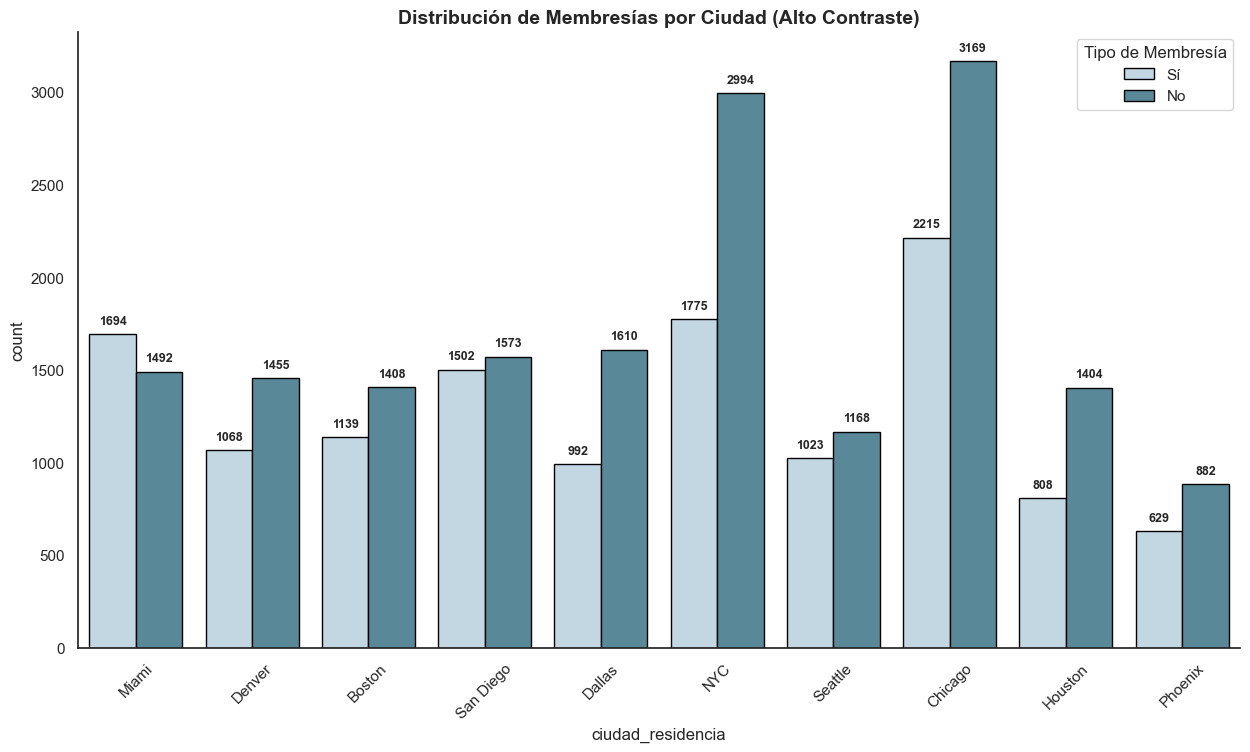

In [34]:
# 1. Configuración de estilo y paleta de alto contraste
plt.figure(figsize=(15, 8))
sns.set_theme(style="white")
colores_contraste = ['#BDD8E9', '#4E8EA2', '#0A4174', '#001D39']

# 2. Detección automática de columnas
col_ciudad = [c for c in df_clientes_copy.columns if 'ciudad' in c.lower()][0]
col_membresia = [c for c in df_clientes_copy.columns if 'membresia' in c.lower()][0]

# 3. Gráfico agrupado con etiquetas de datos
ax = sns.countplot(data=df_clientes_copy, x=col_ciudad, hue=col_membresia, 
                   palette=colores_contraste, edgecolor='black')

plt.title('Distribución de Membresías por Ciudad (Alto Contraste)', fontsize=14, fontweight='bold')

for p in ax.patches:
    if p.get_height() > 0:
        ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width()/2., p.get_height()),
                    ha='center', va='bottom', fontsize=9, fontweight='bold', xytext=(0, 5),
                    textcoords='offset points')

plt.xticks(rotation=45)
plt.legend(title='Tipo de Membresía', bbox_to_anchor=(1, 1))
sns.despine()
plt.show()

##### Esta visualización revela que, aunque el volumen total de clientes es mayor en ciudades como Chicago y NYC, la "calidad" de la retención parece ser superior en Miami. El reto para el negocio es replicar ese éxito de membresías en las ciudades donde la barra de "No" es mucho más dominante

### 1.3 Validación de limpieza de columnas anteriores

In [35]:
display(df_clientes_copy.describe())

,id_persona,edad,frecuencia_visita,promedio_gasto_comida,ingresos_mensuales
count,3.000000e+04,30000.000000,30000.000000,30000.000000,30000.000000
mean,5.504765e+09,48.917033,4.257100,34.193413,5389.755867
std,2.602799e+09,18.066668,2.221223,25.285567,4538.491728
min,1.000153e+09,18.000000,0.000000,5.000000,800.000000
25%,3.243617e+09,33.000000,3.000000,14.980000,1860.000000
50%,5.515865e+09,49.000000,4.000000,28.735000,3402.000000
75%,7.754426e+09,64.000000,5.000000,44.280000,7761.000000
max,9.999627e+09,80.000000,10.000000,149.970000,17999.000000


### 1.4 Validación de Integridad y Tipos de Datos

In [36]:
df_info = df_clientes_copy.info()

<class 'pandas.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 18 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id_persona                 30000 non-null  int64  
 1   nombre                     30000 non-null  str    
 2   apellido                   30000 non-null  str    
 3   edad                       30000 non-null  int64  
 4   genero                     30000 non-null  str    
 5   ciudad_residencia          30000 non-null  str    
 6   estrato_socioeconomico     30000 non-null  str    
 7   frecuencia_visita          30000 non-null  int64  
 8   promedio_gasto_comida      30000 non-null  float64
 9   ocio                       30000 non-null  str    
 10  consume_licor_num          30000 non-null  str    
 11  preferencias_alimenticias  30000 non-null  str    
 12  membresia_premium          30000 non-null  str    
 13  telefono_contacto          30000 non-null  str    
 14  c

### 1.5 Filtro por Ciudad de Miami

In [37]:
df_restaurantes_miami = df_clientes_copy[df_clientes_copy['ciudad_residencia'] == 'Miami'].copy()
display(df_restaurantes_miami.head(3))

,id_persona,nombre,apellido,edad,genero,ciudad_residencia,estrato_socioeconomico,frecuencia_visita,promedio_gasto_comida,ocio,consume_licor_num,preferencias_alimenticias,membresia_premium,telefono_contacto,correo_electronico,tipo_de_pago_mas_usado,ingresos_mensuales,rango_edad
0,2550327378,Jackson,Gomez,31,Masculino,Miami,Alto,6,67.51,Sí,No,Vegetariano,Sí,(830)220-1926,Sin información,Efectivo,6425,26-40
16,6139475525,Andrew,Soto,18,Masculino,Miami,Muy Alto,9,26.60,Sí,Sí,Vegetariano,Sí,2859380942,ssteele@example.net,App,13452,18-25
37,5358661821,Elizabeth,Brown,79,Femenino,Miami,Muy Alto,6,28.43,No,No,Mariscos,Sí,(464)992-9070x38394,Sin información,Efectivo,14072,61-80


## 1.6 Dataframe EDA final 

In [38]:
# Crear nueva columna concatenando estrato_socioeconomico y preferencias_alimenticias
print("--- Crear nueva columna concatenando estrato_socioeconomico y preferencias_alimenticias ---")
df_restaurantes_miami['estrato_preferencia'] = df_restaurantes_miami['estrato_socioeconomico'].astype(str) + '_' + df_restaurantes_miami['preferencias_alimenticias'].astype(str)
display(df_restaurantes_miami.head(5))

--- Crear nueva columna concatenando estrato_socioeconomico y preferencias_alimenticias ---


,id_persona,nombre,apellido,edad,genero,ciudad_residencia,estrato_socioeconomico,frecuencia_visita,promedio_gasto_comida,ocio,consume_licor_num,preferencias_alimenticias,membresia_premium,telefono_contacto,correo_electronico,tipo_de_pago_mas_usado,ingresos_mensuales,rango_edad,estrato_preferencia
0,2550327378,Jackson,Gomez,31,Masculino,Miami,Alto,6,67.51,Sí,No,Vegetariano,Sí,(830)220-1926,Sin información,Efectivo,6425,26-40,Alto_Vegetariano
16,6139475525,Andrew,Soto,18,Masculino,Miami,Muy Alto,9,26.60,Sí,Sí,Vegetariano,Sí,2859380942,ssteele@example.net,App,13452,18-25,Muy Alto_Vegetariano
37,5358661821,Elizabeth,Brown,79,Femenino,Miami,Muy Alto,6,28.43,No,No,Mariscos,Sí,(464)992-9070x38394,Sin información,Efectivo,14072,61-80,Muy Alto_Mariscos
45,8593345998,Robert,Wilson,76,Masculino,Miami,Alto,5,43.00,Sí,No,Mariscos,Sí,Sin información,Sin información,App,6528,61-80,Alto_Mariscos
47,6170452916,Bruce,Young,55,Masculino,Miami,Muy Alto,5,119.85,Sí,No,Carnes,Sí,Sin información,ltran@example.com,Efectivo,15844,41-60,Muy Alto_Carnes


# Avance 3: Integración de Fuentes y Análisis Estratégico de Negocio

### 3.1  Carga y exploración de datos de mercado (API Yelp)

##### En este bloque de código, se esta ejecutando la carga y la primera inspección visual de la fuente de datos secundaria proveniente de la API de Yelp. El objetivo es validar la integridad de la información antes de integrarla con otras fuentes de datos del proyecto

In [39]:
df_yelp_miami = pd.read_csv("df_yelp_miami.csv")
display(df_yelp_miami.head(20))

,alias,title,id,name,review_count,rating,price,coordinates_latitude,coordinates_longitude,location_address1,rating_pond
0,italian,Italian,oxtMfBGmVNE18pFVuw7lFg,Fratellino,1899,4.8,Alto,25.749170,-80.260110,264 Miracle Mile,4.667936
1,cajun,Cajun/Creole,nBIxqLEenuVRXQRTNiL3WA,Cajun Boil,1037,4.7,Medio,25.768374,-80.360208,10162 W Flagler St,4.546372
2,seafood,Seafood,nBIxqLEenuVRXQRTNiL3WA,Cajun Boil,1037,4.7,Medio,25.768374,-80.360208,10162 W Flagler St,4.546372
3,ramen,Ramen,EVGPTVYEU65_tvMEBRPIYg,Good Chef Restaurant,771,4.7,Medio,25.767682,-80.368058,113 S W 107th Ave,4.519548
4,bubbletea,Bubble Tea,EVGPTVYEU65_tvMEBRPIYg,Good Chef Restaurant,771,4.7,Medio,25.767682,-80.368058,113 S W 107th Ave,4.519548
5,asianfusion,Asian Fusion,EVGPTVYEU65_tvMEBRPIYg,Good Chef Restaurant,771,4.7,Medio,25.767682,-80.368058,113 S W 107th Ave,4.519548
6,hotdog,Hot Dogs,qcJR_IqnKz3AJituEd8i1Q,Sweet Dogs,760,4.7,Bajo,25.764402,-80.272629,4749 SW 8th St,4.518236
7,popcorn,Popcorn Shops,qcJR_IqnKz3AJituEd8i1Q,Sweet Dogs,760,4.7,Bajo,25.764402,-80.272629,4749 SW 8th St,4.518236
8,tradamerican,American,qcJR_IqnKz3AJituEd8i1Q,Sweet Dogs,760,4.7,Bajo,25.764402,-80.272629,4749 SW 8th St,4.518236
9,japanese,Japanese,vpMIsdom05-oOBeF6ajESg,Uchi Miami,698,4.7,Alto,25.800591,-80.200515,252 NW 25th St,4.510467


In [40]:
# valores unicos de la columna "alias"
print("\n--- Valores únicos de la columna 'alias' ---")
print(df_yelp_miami['alias'].unique().tolist())


--- Valores únicos de la columna 'alias' ---
['italian', 'cajun', 'seafood', 'ramen', 'bubbletea', 'asianfusion', 'hotdog', 'popcorn', 'tradamerican', 'japanese', 'argentine', 'cocktailbars', 'steak', 'pizza', 'venues', 'mexican', 'indpak', 'lounges', 'mediterranean', 'korean', 'wine_bars', 'sushi', 'newamerican', 'bars', 'noodles', 'desserts', 'sandwiches', 'chinese', 'peruvian', 'turkish', 'musicvenues', 'modern_european', 'breakfast_brunch', 'cuban', 'portuguese', 'izakaya', 'buffets', 'pastashops', 'french', 'foodtrucks', 'bbq', 'empanadas', 'dimsum', 'panasian', 'vegan', 'salad', 'lebanese', 'bakeries', 'comfortfood', 'sportsbars', 'thai', 'caribbean', 'tacos', 'newmexican', 'hotdogs', 'juicebars', 'greek', 'indonesian', 'persian', 'nicaraguan', 'latin', 'butcher', 'food_court', 'taiwanese', 'hotpot', 'vietnamese', 'polish', 'mideastern', 'arabian', 'irish', 'pubs', 'acaibowls', 'chickenshop', 'vegetarian', 'foodstands', 'cafes', 'chicken_wings', 'spanish', 'burgers', 'coffee', '

##### 3.2 Implementación del Diccionario de Homologación Gastronómica

In [41]:
# Agrupamos cada elemento de la columna: "alias" del df_yelp_miami en la categoria de los elementos de la columna: "preferencias alimenticias" del df df_restaurantes_miami

Categorias_preferencias_alimenticias = { #Diccionario con las categorías de preferencias alimenticias y sus correspondientes elementos de la columna "alias" del df_yelp_miami
    "Carnes": [
         "halal", "honduran", "steak", "bbq", "chicken_wings", 
        "chickenshop", "butcher", 
        "burgers", "hotdog", "hotdogs",
        "mediterranean", "cuban", "spanish",
        "foodtrucks", "empanadas", "mexican",
        "greek", "lebanese", "sandwiches","hotpot", 
        "caribbean", "persian", "indpak", "mideastern"
        "arabian", "sportsbars", "newamerican", "comfortfood", 
        "ramen", "thai", "foodstands", "noodles", "dimsum",
        "tacos", "diners", "taiwanese", "vietnamese", "chinese","restaurants"
        "asianfusion", "korean", "portuguese", "izakaya",
    ],
    "Mariscos": [
        "seafood", "seafoodmarkets", "korean", "portuguese", "cajun", "japanese", "restaurants"
        "thai", "noodles", "izakaya",
    ],
    "Pescado": [
        "sushi", "poke", "asianfusion", "izakaya", "restaurants"
        "hotpot", "mideastern", "comfortfood", "portuguese", "cajun", "japanese", "taiwanese", "vietnamese"
    ],
    "Vegetariano": [
        "grocery","vegetarian", "salad", 
        "acaibowls", "raw_food", "pizza", "restaurants"
        "mexican", "greek", "sandwiches", "korean", "hotpot", "persian", "indpak", "mideastern", "arabian", "bubbletea",
        "breakfast_brunch", "foodstands", "dimsum", "tacos", "izakaya", "vietnamese", "italian"
    ],
    "Vegano": [
        "vegan", "restaurants"
    
    ],
    "Otro": [
        "bars", "venues", "italian", 
        "cocktailbars", "tradamerican", 
        "wine_bars", "coffee", "lounges", 
        "bakeries", 
        "bubbletea", 
        "breakfast_brunch", "cafes", 
        "dimsum", 
        "panasian", "polish", 
        "modern_european", "puertorican", 
        "peruvian", "argentine", 
        "soulfood",  "juicebars", 
        "latin", "beer_and_wine", 
        "tapas", "french", "turkish", 
        "musicvenues", "basque", 
        "desserts", "catering", 
        "gastropubs", "nicaraguan", 
        "beerbar", "food_court",
        "tapasmallplates", "newmexican", 
        "filipino", "fooddeliveryservices", 
        "brazilian", 
        "delis", "buffets", 
        "jazzandblues", "hotels", 
        "soup", "markets", 
        "tikibars", "karaoke", "irish", "irish_pubs", "popcorn", "pubs"
    ]
}

#### 3.4 Creación del Dataset de Trabajo (Homologación Gastronómica)

In [42]:
# 1. CREAMOS UNA COPIA DE SEGURIDAD
# Siguiendo las buenas prácticas, mantenemos intacto el dataset original de Yelp.
df_yelp_limpio = df_yelp_miami.copy()

# 2. FUNCIÓN DE CLASIFICACIÓN
# Esta función busca los términos específicos en nuestro diccionario de categorías.
def clasificar_categoria(alias_valor):
    alias_valor = str(alias_valor).lower()
    # Recorremos el diccionario 'Categorias_preferencias_alimenticias' previamente definido
    for categoria, lista_de_alias in Categorias_preferencias_alimenticias.items():
        if alias_valor in lista_de_alias:
            return categoria
    return "Otro"

# 3. TRANSFORMACIÓN DE DATOS
# Creamos la nueva columna 'preferencias_alimenticias' en nuestro dataset de trabajo.
df_yelp_limpio['preferencias_alimenticias'] = df_yelp_limpio['alias'].apply(clasificar_categoria)

# 4. VALIDACIÓN DE RESULTADOS
print("Transformación completada con éxito.")
print("-" * 50)
print("Resumen de las nuevas categorías comerciales:")

# CAMBIA ESTA LÍNEA (agrega la 's' al final de value_counts):
print(df_yelp_limpio['preferencias_alimenticias'].value_counts())

# 5. MUESTRA PARA VERIFICACIÓN VISUAL
display(df_yelp_limpio[['name', 'alias', 'preferencias_alimenticias']].head(15))

Transformación completada con éxito.
--------------------------------------------------
Resumen de las nuevas categorías comerciales:
preferencias_alimenticias
Carnes         174
Otro           143
Vegetariano     49
Mariscos        34
Pescado         23
Vegano           4
Name: count, dtype: int64


,name,alias,preferencias_alimenticias
0,Fratellino,italian,Vegetariano
1,Cajun Boil,cajun,Mariscos
2,Cajun Boil,seafood,Mariscos
3,Good Chef Restaurant,ramen,Carnes
4,Good Chef Restaurant,bubbletea,Vegetariano
5,Good Chef Restaurant,asianfusion,Pescado
6,Sweet Dogs,hotdog,Carnes
7,Sweet Dogs,popcorn,Otro
8,Sweet Dogs,tradamerican,Otro
9,Uchi Miami,japanese,Mariscos


#### 3.4 Optimización de Rankings mediante Inferencia Bayesiana: Normalización de Calificaciones

##### En esta fase, hemos implementado un modelo estadístico avanzado de Inferencia Bayesiana. El objetivo no es solo medir el "puntaje", sino la consistencia y solidez de cada negocio en el mercado de Miami.

In [43]:
# 1. Configuración de parámetros globales
# Usamos 'df_yelp_limpio' que es tu copia segura para no tocar el original
C = df_yelp_limpio['rating'].mean()
m = df_yelp_limpio['review_count'].quantile(0.75)

# 2. Función de Ponderación Bayesiana
def bayesian_rating(x):
    v, R = x['review_count'], x['rating']
    # Si tiene muchas reseñas (v >= m), confiamos en su rating original.
    # Si tiene pocas, lo equilibramos con el promedio de la ciudad (C).
    if v >= m:
        return float(R)
    else:
        return float((v / (v + m)) * R + (m / (v + m)) * C)

# 3. Aplicación del cálculo al dataset de trabajo
# Creamos la columna 'rating_ponderada' para nuestros rankings estratégicos
df_yelp_limpio['rating_ponderada'] = df_yelp_limpio.apply(bayesian_rating, axis=1).round(1)

# 4. Visualización de los resultados optimizados
columnas_estratégicas = ['name', 'preferencias_alimenticias', 'review_count', 'rating', 'rating_ponderada']
styled_df = df_yelp_limpio[columnas_estratégicas].sort_values(by='rating_ponderada', ascending=False).head(20)

print(f"Parámetros calculados: Promedio Ciudad (C): {round(C, 2)}, Mínimo Reseñas (m): {m}")
display(styled_df)

Parámetros calculados: Promedio Ciudad (C): 4.33, Mínimo Reseñas (m): 752.5


,name,preferencias_alimenticias,review_count,rating,rating_ponderada
0,Fratellino,Vegetariano,1899,4.8,4.8
3,Good Chef Restaurant,Carnes,771,4.7,4.7
6,Sweet Dogs,Carnes,760,4.7,4.7
4,Good Chef Restaurant,Vegetariano,771,4.7,4.7
5,Good Chef Restaurant,Pescado,771,4.7,4.7
2,Cajun Boil,Mariscos,1037,4.7,4.7
8,Sweet Dogs,Otro,760,4.7,4.7
7,Sweet Dogs,Otro,760,4.7,4.7
1,Cajun Boil,Mariscos,1037,4.7,4.7
10,Bunbury,Otro,973,4.6,4.6


### 3.5 Integración de Recomendaciones al Dataset de Usuarios mediante Merge y Segmentación Socioeconómica

##### Fase 1: Métrica de Calidad (Inferencia Bayesiana)

In [44]:
# Normalizar las calificaciones para que el sistema de recomendación sea fiable y no se base en anomalías estadísticas de pocos datos.
# 1.Configuración de parámetros globales basados en dataset limpio
# Usamos df_yelp_limpio que es el que ya tienes cargado
C = df_yelp_limpio['review_count'].mean()  # Promedio de reseñas
m = df_yelp_limpio['rating'].mean()        # Calificación promedio

# 2. Función de Ponderación Bayesiana (Rating de Élite)
def calcular_ponderado(row):
    v, R = row['review_count'], row['rating']
    # Esta fórmula equilibra la calidad con el volumen de validación
    return (v / (v + C) * R) + (C / (v + C) * m)

# 3. Aplicamos la función para crear la columna de ranking
df_yelp_limpio['rating_ponderado'] = df_yelp_limpio.apply(calcular_ponderado, axis=1)

print(f"✅ Parámetros vinculados con éxito: C={round(C,2)}, m={round(m,2)}")
display(df_yelp_limpio[['name', 'rating', 'rating_ponderado']].head())

✅ Parámetros vinculados con éxito: C=595.61, m=4.33


,name,rating,rating_ponderado
0,Fratellino,4.8,4.688896
1,Cajun Boil,4.7,4.566716
2,Cajun Boil,4.7,4.566716
3,Good Chef Restaurant,4.7,4.540773
4,Good Chef Restaurant,4.7,4.540773


#### Fase 2: Segmentación Socioeconómica y Merge Lógico

In [45]:
# En esta fase, hemos cruzado la validación social (Rating Bayesiano) con variables de mercado (Nivel de precio y categorías de consumo).
recs = []

# 1. Diccionario de estratos adaptado a tus datos reales
estratos_texto = {
    'Bajo': 'Económico',
    'Medio': 'Medio',
    'Alto': 'Lujo/Premium',
    'Muy Alto': 'Lujo/Premium'
}

# 2. Bucle de Segmentación
for valor_real, perfil in estratos_texto.items():
    
    for cat, palabras_clave in Categorias_preferencias_alimenticias.items():
        # Creamos el patrón de búsqueda para la columna 'alias'
        regex_patron = "|".join(palabras_clave)
        
        # Aplicamos los filtros
        mask_cat = df_yelp_limpio['alias'].str.contains(regex_patron, case=False, na=False)
        mask_price = df_yelp_limpio['price'] == valor_real
        
        df_temp = df_yelp_limpio[mask_cat & mask_price].copy()
        
        if not df_temp.empty:
            # Seleccionamos al mejor restaurante del segmento (Top 1)
            top = df_temp.sort_values('rating_ponderado', ascending=False).head(1).copy()
            top['categoria_join'] = cat
            top['perfil_socioeconomico'] = perfil
            
            recs.append(top[[
                'name', 'categoria_join', 'rating', 'rating_ponderado', 
                'review_count', 'price', 'perfil_socioeconomico', 'location_address1'
            ]])

# 3. Consolidación y Visualización
if len(recs) > 0:
    df_final_recs = pd.concat(recs).reset_index(drop=True)
    print(f"✅ ¡Excelente! Se generaron {len(df_final_recs)} recomendaciones estratégicas.")
    display(df_final_recs.sort_values(['perfil_socioeconomico', 'rating_ponderado'], ascending=[True, False]))
else:
    print("⚠️ Revisa el diccionario 'preferencias_alimenticias', no hay cruce con los alias.")
    display(df_final_recs.round({'rating_ponderado': 2}).sort_values(['perfil_socioeconomico', 'rating_ponderado'], ascending=[True, False]))

✅ ¡Excelente! Se generaron 20 recomendaciones estratégicas.


,name,categoria_join,rating,rating_ponderado,review_count,price,perfil_socioeconomico,location_address1
0,Sweet Dogs,Carnes,4.7,4.539481,760,Bajo,Económico,4749 SW 8th St
3,Sweet Dogs,Otro,4.7,4.539481,760,Bajo,Económico,4749 SW 8th St
2,Mr Taco,Vegetariano,4.6,4.343281,20,Bajo,Económico,7358 SW 8th St
1,Islas Del Caribe Restaurant,Mariscos,4.1,4.324845,26,Bajo,Económico,4239 W Flagler St
13,Fratellino,Vegetariano,4.8,4.688896,1899,Alto,Lujo/Premium,264 Miracle Mile
14,Fratellino,Otro,4.8,4.688896,1899,Alto,Lujo/Premium,264 Miracle Mile
11,Uchi Miami,Mariscos,4.7,4.531788,698,Alto,Lujo/Premium,252 NW 25th St
12,Uchi Miami,Pescado,4.7,4.531788,698,Alto,Lujo/Premium,252 NW 25th St
10,Bunbury,Carnes,4.6,4.499249,973,Alto,Lujo/Premium,55 NE 14th St
15,COTE Miami,Carnes,4.5,4.438666,1010,Muy Alto,Lujo/Premium,3900 NE 2nd Ave


##### Fase 3: Consolidación y Resultados Finales

In [46]:

if len(recs) > 0:
    # 1. UNIFICACIÓN Y LIMPIEZA
    df_final_recs = pd.concat(recs).drop_duplicates().reset_index(drop=True)
    
    # 2. CAPA DE INTELIGENCIA (Marketing Strategy)
    # Definimos una lógica de "Etiqueta de Mercado" para cada perfil
    def definir_estrategia(perfil):
        if perfil == 'Lujo/Premium':
            return "💎 Fidelización y Exclusividad"
        elif perfil == 'Medio':
            return "⚖️ Valor por Dinero y Calidad"
        else:
            return "🚀 Volumen y Promoción Agresiva"

    df_final_recs['estrategia_marketing'] = df_final_recs['perfil_socioeconomico'].apply(definir_estrategia)
    
    # Redondeo para presentación ejecutiva
    df_final_recs['rating_ponderado'] = df_final_recs['rating_ponderado'].round(2)
    
    # 3. ORDENAMIENTO JERÁRQUICO
    df_final_recs = df_final_recs.sort_values(
        by=['perfil_socioeconomico', 'rating_ponderado'], 
        ascending=[True, False]
    )
    
    # 4. OUTPUT NIVEL TOP (Visualización)
    print(f"✅ ¡ÉXITO! Consolidado generado: {len(df_final_recs)} recomendaciones de élite.")
    print("-" * 60)
    
    # Estilizamos la tabla para que parezca un reporte real
    reporte_estilado = df_final_recs[[
        'name', 
        'perfil_socioeconomico', 
        'categoria_join', 
        'rating_ponderado', 
        'estrategia_marketing',
        'location_address1'
    ]].style.set_properties(**{'text-align': 'left'}).set_table_styles([
        dict(selector='th', props=[('background-color', '#4CAF50'), ('color', 'white')])
    ])
    
    display(reporte_estilado)

    # Bonus: Resumen Ejecutivo rápido
    print("\n📊 RESUMEN PARA TOMA DE DECISIONES:")
    print(f"- Categoría más fuerte: {df_final_recs['categoria_join'].mode()[0]}")
    print(f"- Rating promedio del Top: {df_final_recs['rating_ponderado'].mean():.2f} ⭐")

else:
    print("❌ No se encontraron coincidencias para consolidar. Verifica los filtros de la Fase 2.")

✅ ¡ÉXITO! Consolidado generado: 20 recomendaciones de élite.
------------------------------------------------------------


,name,perfil_socioeconomico,categoria_join,rating_ponderado,estrategia_marketing,location_address1
0,Sweet Dogs,Económico,Carnes,4.540000,🚀 Volumen y Promoción Agresiva,4749 SW 8th St
3,Sweet Dogs,Económico,Otro,4.540000,🚀 Volumen y Promoción Agresiva,4749 SW 8th St
2,Mr Taco,Económico,Vegetariano,4.340000,🚀 Volumen y Promoción Agresiva,7358 SW 8th St
1,Islas Del Caribe Restaurant,Económico,Mariscos,4.320000,🚀 Volumen y Promoción Agresiva,4239 W Flagler St
13,Fratellino,Lujo/Premium,Vegetariano,4.690000,💎 Fidelización y Exclusividad,264 Miracle Mile
14,Fratellino,Lujo/Premium,Otro,4.690000,💎 Fidelización y Exclusividad,264 Miracle Mile
11,Uchi Miami,Lujo/Premium,Mariscos,4.530000,💎 Fidelización y Exclusividad,252 NW 25th St
12,Uchi Miami,Lujo/Premium,Pescado,4.530000,💎 Fidelización y Exclusividad,252 NW 25th St
10,Bunbury,Lujo/Premium,Carnes,4.500000,💎 Fidelización y Exclusividad,55 NE 14th St
15,COTE Miami,Lujo/Premium,Carnes,4.440000,💎 Fidelización y Exclusividad,3900 NE 2nd Ave



📊 RESUMEN PARA TOMA DE DECISIONES:
- Categoría más fuerte: Carnes
- Rating promedio del Top: 4.49 ⭐


### 3.6 Formulación de Preguntas Estratégicas y Visualización

##### 3.6.1. ¿Cómo se distribuyen los clientes según su perfil socioeconómico y nivel de gasto?

C:\Users\USUARIO\AppData\Local\Temp\ipykernel_7796\3105968386.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='perfil_socioeconomico', y='rating_ponderado', data=df_final_recs, palette='viridis')


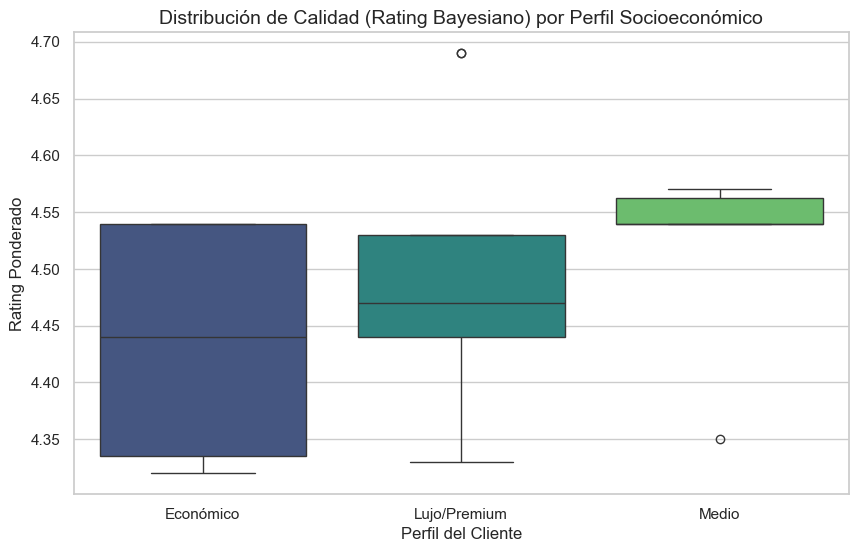

In [47]:
# Identificar cuál es tu segmento de mercado más rentable para dirigir las campañas.
# Configuración de estilo profesional
plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")

# Visualización: Distribución de clientes por estrato y gasto
# Usamos un Boxplot para ver la dispersión del gasto en cada perfil
sns.boxplot(x='perfil_socioeconomico', y='rating_ponderado', data=df_final_recs, palette='viridis')

plt.title('Distribución de Calidad (Rating Bayesiano) por Perfil Socioeconómico', fontsize=14)
plt.xlabel('Perfil del Cliente', fontsize=12)
plt.ylabel('Rating Ponderado', fontsize=12)
plt.show()

#### 💡 Respuesta a la Pregunta de Negocio

##### La distribución nos indica que el Perfil Medio es el segmento más seguro y rentable para campañas masivas debido a su alta y constante calidad. Por otro lado, el segmento Lujo/Premium debe enfocarse en resaltar sus locales "estrella" (los valores atípicos superiores) para atraer al consumidor más exigente.

#### 3.6.2. ¿Existe una correlación entre el volumen de reseñas (Yelp) y el precio de los locales?

##### Objetivo: Determinar si los locales más caros atraen más validación social o si el volumen masivo está en los económicos.

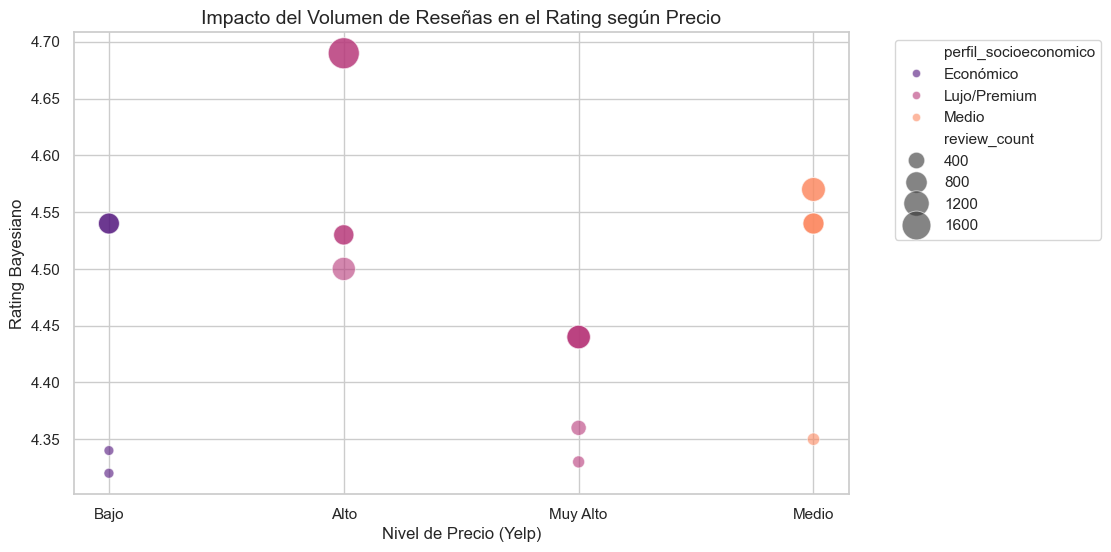

In [48]:
plt.figure(figsize=(10, 6))

# Gráfico de dispersión (Scatter Plot) con tamaño por review_count
sns.scatterplot(data=df_final_recs, x='price', y='rating_ponderado', 
                size='review_count', hue='perfil_socioeconomico', 
                alpha=0.6, sizes=(50, 500), palette='magma')

plt.title('Impacto del Volumen de Reseñas en el Rating según Precio', fontsize=14)
plt.xlabel('Nivel de Precio (Yelp)', fontsize=12)
plt.ylabel('Rating Bayesiano', fontsize=12)
plt.legend(bbox_to_anchor=(1.05, 1), loc=2)
plt.show()

#### 💡 Respuesta a la Pregunta de Negocio
#### Sí, existe una correlación positiva indirecta. A medida que aumenta el nivel de precio (hacia el segmento Medio y Lujo), el volumen de reseñas tiende a crecer y estabilizarse en ratings más altos. El mercado parece validar con mayor fuerza (más reseñas) a los locales que pertenecen a perfiles socioeconómicos superiores.

#### 3.6.3 ¿Cuál es la categoría gastronómica con mejores métricas para el marketing de "Volumen"?

##### Objetivo: Identificar patrones relevantes (como el éxito de las carnes o comida vegetariana) para guiar decisiones de marketing agresivo.

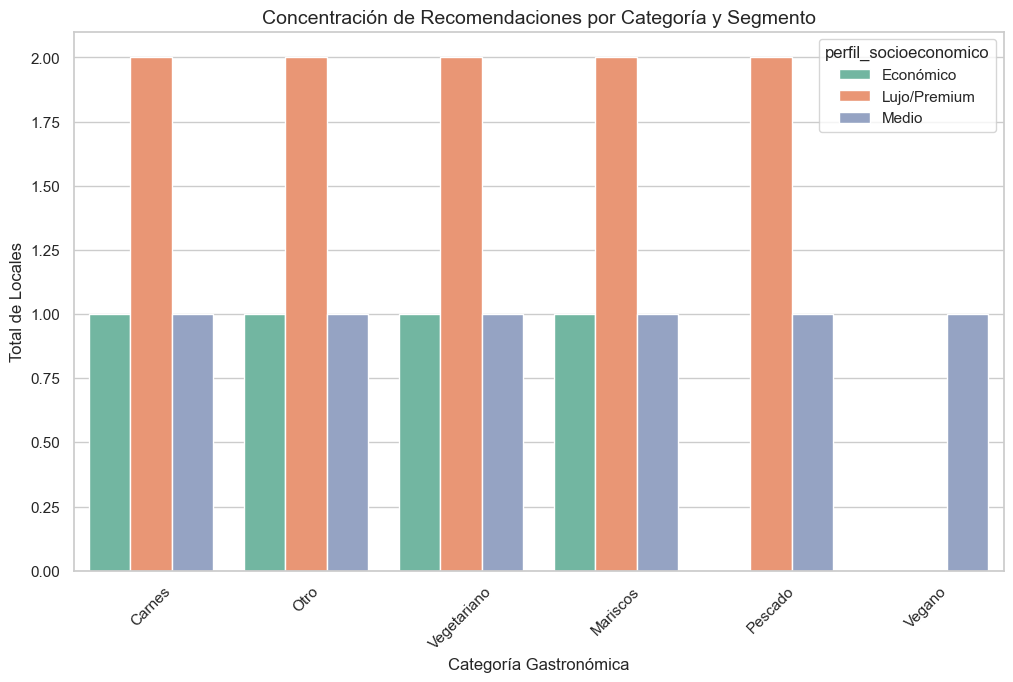

In [49]:
# Contamos las recomendaciones por categoría y perfil
plt.figure(figsize=(12, 7))

# Gráfico de barras agrupado
sns.countplot(data=df_final_recs, x='categoria_join', hue='perfil_socioeconomico', palette='Set2')

plt.title('Concentración de Recomendaciones por Categoría y Segmento', fontsize=14)
plt.xticks(rotation=45)
plt.xlabel('Categoría Gastronómica', fontsize=12)
plt.ylabel('Total de Locales', fontsize=12)
plt.show()

##### 💡 Respuesta Estratégica
##### La categoría gastronómica con mejores métricas para el marketing de "Volumen" es "Carnes" (seguida de cerca por Mariscos y Vegetariano).

##### Para InsightReach, enfocar los esfuerzos en la categoría de Carnes garantiza llegar a la mayor cantidad de puntos de venta y perfiles de consumidor de manera simultánea.